# Bài tập buổi 13: Xây dựng mạng MLP trên EMNIST

Đề bài : Xây dựng pipeline huấn luyện một mạng MLP (Multi-Layer Perceptron) để phân loại **chữ cái in hoa** trong dataset **EMNIST** (A–Z, 26 lớp).

Mục tiêu:
- Tải và chuẩn bị dữ liệu EMNIST bằng `torchvision`.
- Định nghĩa mô hình MLP bằng `nn.Module`.
- Viết vòng lặp huấn luyện và đánh giá.
- Trực quan hóa kết quả và lưu mô hình.

Kết quả tham khảo: MLP đơn giản này thường đạt khoảng **85–90%** accuracy trên tập test.

**Sinh viên thực hiện:** Nguyễn Huỳnh Nam Quốc  
**MSSV:** 2453089

## 1. Import và cấu hình

Import các thư viện cần thiết rồi đặt các tham số huấn luyện.

Gợi ý: `BATCH_SIZE = 256`, `EPOCHS = 5`, `LEARNING_RATE = 1e-3`. Chọn `DEVICE` là `cuda` nếu có GPU, ngược lại dùng `cpu`.

In [14]:
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from torchvision import datasets, transforms

BATCH_SIZE = 256
EPOCHS = 8
LEARNING_RATE = 1e-3
DATA_DIR = "./data"

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

torch.manual_seed(0)

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("GPU:", torch.cuda.get_device_name(0))
print(
    "VRAM:",
    round(
        torch.cuda.get_device_properties(0).total_memory / 1024**3,
        2
    ),
    "GB"
)

PyTorch: 2.11.0+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.0 GB


## 2. Dataset và DataLoader

Tải dataset EMNIST với `split='letters'` (26 lớp chữ cái in hoa A–Z, ảnh xám 28×28).

- Dùng `transforms.Compose([transforms.ToTensor()])` để đổi ảnh thành tensor.
- Tách tập train gốc (124.800 mẫu) thành **100.000 mẫu train** và **24.800 mẫu validation**.
- Tạo 3 `DataLoader` với `batch_size=BATCH_SIZE`; chỉ `train_loader` cần `shuffle=True`.

In [15]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

# EMNIST letters dùng nhãn 1..26 trong torchvision.
# Chuyển về 0..25 để dùng với CrossEntropyLoss + 26 output classes.
target_transform = lambda y: y - 1

full_train = datasets.EMNIST(
    DATA_DIR,
    split="letters",
    train=True,
    transform=transform,
    target_transform=target_transform,
    download=True
)

test_set = datasets.EMNIST(
    DATA_DIR,
    split="letters",
    train=False,
    transform=transform,
    target_transform=target_transform,
    download=True
)

generator = torch.Generator().manual_seed(0)

train_set, val_set = random_split(
    full_train,
    [100000, 24800],
    generator=generator
)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train:", len(train_set))
print("Validation:", len(val_set))
print("Test:", len(test_set))

Train: 100000
Validation: 24800
Test: 20800


## 3. Khám phá dữ liệu

In shape của một batch rồi vẽ vài ảnh đầu tiên để xem dữ liệu trông như thế nào.

Lưu ý: nhãn là số nguyên 0–25, tương ứng với chữ cái A–Z. Có thể đổi sang ký tự bằng `chr(nhãn + ord('A'))`.

Batch ảnh : torch.Size([256, 1, 28, 28])
Batch nhãn: torch.Size([256])


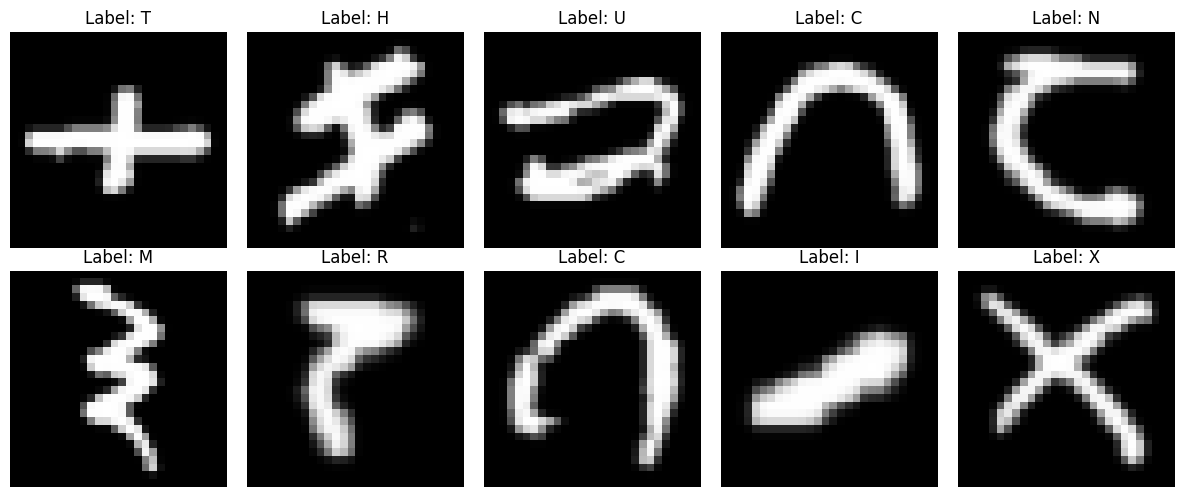

In [16]:
batch_images, batch_labels = next(iter(train_loader))

print("Batch ảnh :", batch_images.shape)
print("Batch nhãn:", batch_labels.shape)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.ravel()):
    image = batch_images[i].squeeze()
    label = int(batch_labels[i])

    letter = chr(label + ord("A"))

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {letter}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Định nghĩa MLP

Xây dựng lớp `EMNISTMLP` kế thừa `nn.Module`.

Gợi ý cấu trúc: `Flatten` → `Linear(784, 128)` → `ReLU` → `Linear(128, 26)`.
Chú ý: 784 = 28×28 (kích thước ảnh sau khi dẹt), 26 = số lớp chữ cái.

In [17]:
class EMNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),

            nn.Linear(128, 26)
        )

    def forward(self, images):
        return self.network(images)


model = EMNISTMLP().to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

print(model)

EMNISTMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.1, inplace=False)
    (7): Linear(in_features=128, out_features=26, bias=True)
  )
)


## 5. Vòng lặp huấn luyện và đánh giá

Viết 2 hàm:

- `train_one_epoch`: với mỗi batch, thực hiện `zero_grad` → forward → tính loss → `backward` → `step`. Cộng dồn loss và số dự đoán đúng.
- `evaluate`: giống vòng lặp trên nhưng **không cập nhật trọng số**, dùng `model.eval()` và `torch.no_grad()`.

Cả hai hàm trả về `(loss trung bình, accuracy)`.

In [18]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, labels)

        loss.backward()

        optimizer.step()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size

        predictions = logits.argmax(dim=1)

        total_correct += (
            predictions == labels
        ).sum().item()

        total_samples += batch_size

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return avg_loss, accuracy

## 6. Huấn luyện

Chạy vòng lặp qua `EPOCHS` epoch. Mỗi epoch: train 1 epoch trên `train_loader`, đánh giá trên `val_loader`, lưu loss/accuracy vào các list và in kết quả.

In [19]:
def evaluate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():

        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model(images)

            loss = criterion(logits, labels)

            batch_size = labels.size(0)

            total_loss += loss.item() * batch_size

            predictions = logits.argmax(dim=1)

            total_correct += (
                predictions == labels
            ).sum().item()

            total_samples += batch_size

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return avg_loss, accuracy

## 7. Đánh giá và trực quan hóa

1. Vẽ 2 biểu đồ cạnh nhau: **Loss** và **Accuracy** theo epoch (so sánh train vs val).
2. Đánh giá mô hình trên `test_loader` (tập chưa từng dùng khi huấn luyện).
3. Lấy 1 batch từ `test_loader`, vẽ 10 ảnh với nhãn thật và nhãn dự đoán (xanh = đúng, đỏ = sai).

In [20]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(1, EPOCHS + 1):

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_accuracy = evaluate(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss={train_loss:.4f} | "
        f"val loss={val_loss:.4f} | "
        f"train acc={train_accuracy:.2%} | "
        f"val acc={val_accuracy:.2%}"
    )

Epoch 01/8 | train loss=1.1788 | val loss=0.6234 | train acc=65.63% | val acc=81.22%
Epoch 02/8 | train loss=0.6036 | val loss=0.4525 | train acc=81.59% | val acc=86.22%
Epoch 03/8 | train loss=0.4793 | val loss=0.3892 | train acc=85.05% | val acc=87.77%
Epoch 04/8 | train loss=0.4224 | val loss=0.3451 | train acc=86.61% | val acc=89.28%
Epoch 05/8 | train loss=0.3821 | val loss=0.3267 | train acc=87.87% | val acc=89.62%
Epoch 06/8 | train loss=0.3533 | val loss=0.3102 | train acc=88.62% | val acc=90.28%
Epoch 07/8 | train loss=0.3312 | val loss=0.2972 | train acc=89.26% | val acc=90.57%
Epoch 08/8 | train loss=0.3128 | val loss=0.2836 | train acc=89.68% | val acc=91.14%


## 8. Lưu mô hình

Lưu trọng số của mô hình bằng `state_dict` để dùng lại sau này.

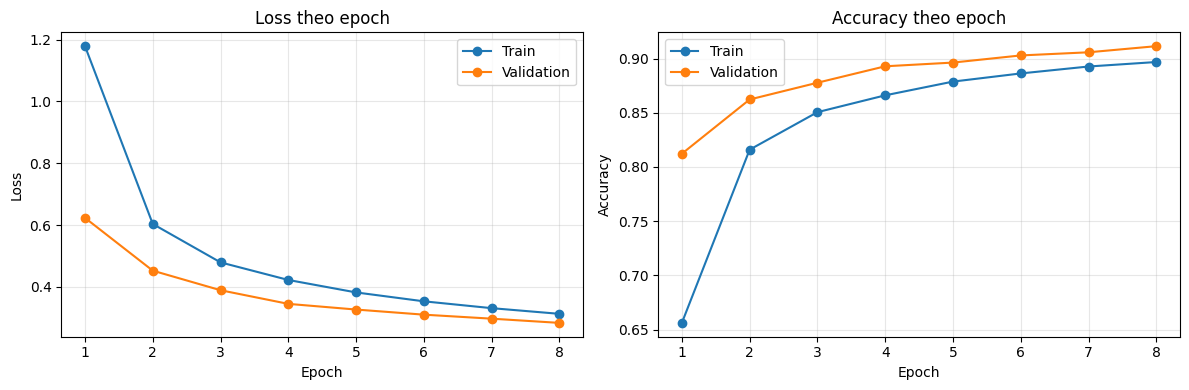

In [21]:
epochs = range(1, EPOCHS + 1)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

# Loss
axes[0].plot(
    epochs,
    train_losses,
    marker="o",
    label="Train"
)

axes[0].plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation"
)

axes[0].set_title("Loss theo epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)


# Accuracy
axes[1].plot(
    epochs,
    train_accuracies,
    marker="o",
    label="Train"
)

axes[1].plot(
    epochs,
    val_accuracies,
    marker="o",
    label="Validation"
)

axes[1].set_title("Accuracy theo epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Test accuracy

In [22]:
test_loss, test_accuracy = evaluate(
    model,
    test_loader,
    criterion
)

print(f"Test loss     = {test_loss:.4f}")
print(f"Test accuracy = {test_accuracy:.2%}")

Test loss     = 0.2962
Test accuracy = 90.72%


## 10 dự đoán test

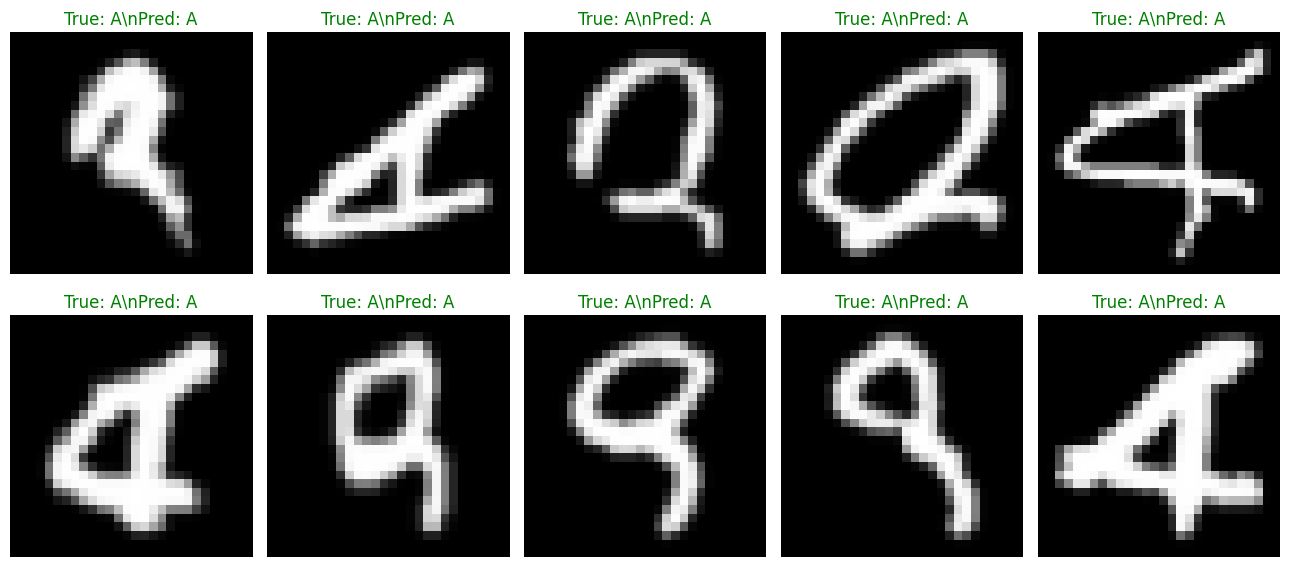

In [23]:
test_images, test_labels = next(
    iter(test_loader)
)

test_images_device = test_images.to(DEVICE)

model.eval()

with torch.no_grad():
    logits = model(test_images_device)
    predictions = logits.argmax(dim=1).cpu()


fig, axes = plt.subplots(
    2,
    5,
    figsize=(13, 6)
)

for i, ax in enumerate(axes.ravel()):

    image = test_images[i].squeeze()

    true_label = int(test_labels[i])
    pred_label = int(predictions[i])

    true_letter = chr(
        true_label + ord("A")
    )

    pred_letter = chr(
        pred_label + ord("A")
    )

    correct = true_label == pred_label

    title_color = (
        "green" if correct else "red"
    )

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title(
        f"True: {true_letter}\\nPred: {pred_letter}",
        color=title_color
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

## Lưu model

In [24]:
MODEL_PATH = "emnist_mlp.pt"

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print(
    f"Đã lưu model vào: {MODEL_PATH}"
)

Đã lưu model vào: emnist_mlp.pt


## Nhận xét

Sau 8 epoch, loss trên tập train giảm từ khoảng 1.1788 xuống 0.3128, trong khi validation loss giảm từ 0.6234 xuống 0.2836. Accuracy cũng tăng đều qua các epoch, cho thấy mô hình đã học được khá tốt các đặc trưng để phân biệt 26 lớp chữ cái của EMNIST.

Kết quả cuối cùng trên tập test đạt **90.72% accuracy**, cao hơn mức 85% yêu cầu của bài. Validation accuracy ở epoch cuối đạt khoảng **91.14%**, khá gần với kết quả trên test nên em thấy mô hình có khả năng tổng quát hóa tương đối tốt.

Train accuracy ở epoch cuối khoảng **89.68%**, thấp hơn validation accuracy một chút. Em nghĩ điều này vẫn hợp lý vì trong lúc train mô hình có sử dụng Dropout, còn khi validation thì Dropout được tắt bởi `model.eval()`.

Nhìn vào các ảnh dự đoán test, phần lớn chữ cái được nhận dạng đúng nhưng mô hình vẫn có thể nhầm một số ký tự có nét tương đối giống nhau. Vì MLP flatten toàn bộ ảnh thành vector nên chưa tận dụng trực tiếp cấu trúc không gian của ảnh; nếu dùng CNN thì có thể khai thác đặc trưng hình ảnh tốt hơn.